# Lorenz-63 and 4D-Var Demo

This notebook provides a reproducible baseline demo of data assimilation on the Lorenz-63 system:

- Generate and visualize Lorenz-63 trajectories
- Build simple train/test pairs for one-step prediction intuition
- Run a 4D-Var experiment to recover an initial condition from noisy observations
- Study how observation frequency and noise affect reconstruction quality

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize

# Reproducibility
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

# Plot defaults
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True


def lorenz63_ode(x, t, sigma, rho, beta_lorenz):
    """Lorenz-63 ODE right-hand side."""
    return [
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta_lorenz * x[2],
    ]


def build_observations(x_true_window, obs_step, sigma_y, rng):
    """Observe only x1 at regularly spaced times with additive Gaussian noise."""
    obs_indices = np.arange(0, x_true_window.shape[0], obs_step)
    y_obs = x_true_window[obs_indices, 0] + rng.normal(0.0, sigma_y, size=len(obs_indices))
    return obs_indices, y_obs


def cost_function(
    x0_guess,
    x_b,
    B_inv,
    y_obs,
    inv_R,
    obs_indices,
    L,
    dt,
    sigma,
    rho,
    beta_lorenz,
    ):
    """4D-Var cost J(x0) = J_b + J_o for partial noisy observations of x1."""
    # Background term
    diff_b = x0_guess - x_b
    J_b = 0.5 * diff_b.T @ B_inv @ diff_b

    # Observation term
    t_eval = np.arange(0.0, L * dt, dt)
    traj = odeint(lorenz63_ode, x0_guess, t_eval, args=(sigma, rho, beta_lorenz))

    innovations = traj[obs_indices, 0] - y_obs
    J_o = 0.5 * inv_R * np.sum(innovations**2)

    return float(J_b + J_o)


def run_4dvar(
    x_true_window,
    x_b_initial,
    obs_step,
    sigma_y,
    L,
    dt,
    sigma,
    rho,
    beta_lorenz,
    rng,
    maxiter=200,
    ):
    """Run one 4D-Var experiment and return diagnostics."""
    obs_indices, y_obs = build_observations(x_true_window, obs_step, sigma_y, rng)

    # Covariances (simple isotropic setup for this demo)
    B = np.eye(3) * 4.0
    B_inv = np.linalg.inv(B)
    R = np.array([[sigma_y**2]])
    inv_R = 1.0 / R[0, 0]

    res = minimize(
        fun=cost_function,
        x0=x_b_initial,
        args=(
            x_b_initial,
            B_inv,
            y_obs,
            inv_R,
            obs_indices,
            L,
            dt,
            sigma,
            rho,
            beta_lorenz,
        ),
        method="L-BFGS-B",
        options={"maxiter": maxiter},
    )

    t_eval = np.arange(0.0, L * dt, dt)
    x_analysis = odeint(lorenz63_ode, res.x, t_eval, args=(sigma, rho, beta_lorenz))
    x_background = odeint(lorenz63_ode, x_b_initial, t_eval, args=(sigma, rho, beta_lorenz))
    rmse = float(np.sqrt(np.mean((x_true_window - x_analysis) ** 2)))

    return {
        "result": res,
        "obs_indices": obs_indices,
        "y_obs": y_obs,
        "x_analysis": x_analysis,
        "x_background": x_background,
        "rmse": rmse,
    }

## 1) Generate Lorenz-63 Data

The Lorenz-63 model is
$$
\dot{x}_1 = \sigma(x_2-x_1), \quad
\dot{x}_2 = x_1(\rho-x_3)-x_2, \quad
\dot{x}_3 = x_1x_2-\beta x_3.
$$

We use the classical parameters $\sigma=10$, $\rho=28$, and $\beta=8/3$.

In [2]:
# Simulation parameters
x0 = np.array([8.0, 0.0, 30.0])
dt = 0.01
T = 100.0
sigma = 10.0
rho = 28.0
beta_lorenz = 8.0 / 3.0

t = np.arange(0.0, T, dt)
x = odeint(lorenz63_ode, x0, t, args=(sigma, rho, beta_lorenz))

print(f"Trajectory shape: {x.shape}, time steps: {len(t)}")

Trajectory shape: (10000, 3), time steps: 10000


## 2) Visualize the Dynamics

Two complementary views:
- Time-series of each state variable
- 3D phase-space trajectory

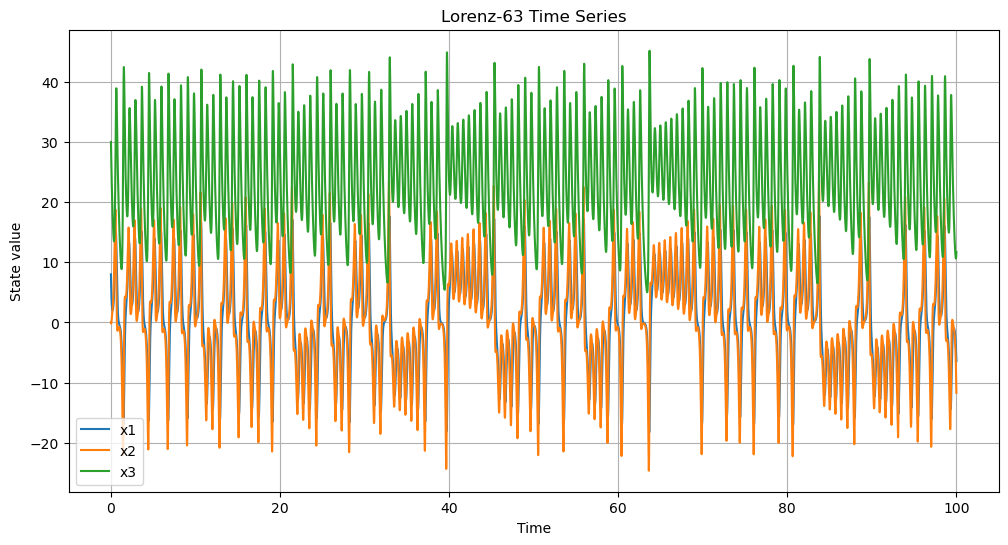

In [3]:
plt.figure()
plt.plot(t, x[:, 0], label="x1")
plt.plot(t, x[:, 1], label="x2")
plt.plot(t, x[:, 2], label="x3")
plt.xlabel("Time")
plt.ylabel("State value")
plt.title("Lorenz-63 Time Series")
plt.legend()
plt.show()

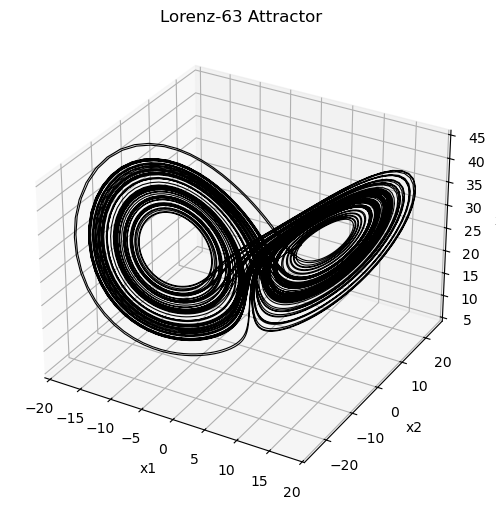

In [4]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(x[:, 0], x[:, 1], x[:, 2], color="black", linewidth=0.8)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Lorenz-63 Attractor")
plt.show()

## 3) Build One-Step Pairs

For intuition, we create one-step supervised pairs:
- Input: $x(t)$
- Target: $x(t+dt)$

We split into train/test chronologically.

In [5]:
T_train = int(len(x) * 2 / 3)

x_train = x[:T_train, :]
y_train = x[1 : T_train + 1, :]

x_test = x[T_train:-1, :]
y_test = x[T_train + 1 :, :]

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}, y_test:  {y_test.shape}")

x_train: (6666, 3), y_train: (6666, 3)
x_test:  (3333, 3), y_test:  (3333, 3)


In [6]:
# Quick sanity check
assert x_train.shape == y_train.shape
assert x_test.shape == y_test.shape
print("Train/test pair shapes are consistent.")

Train/test pair shapes are consistent.


In [7]:
# Optional preview
x_train[:3], y_train[:3]

(array([[ 8.        ,  0.        , 30.        ],
        [ 7.23222354, -0.12174368, 29.20559537],
        [ 6.52926983, -0.17666531, 28.42663662]]),
 array([[ 7.23222354, -0.12174368, 29.20559537],
        [ 6.52926983, -0.17666531, 28.42663662],
        [ 5.89067205, -0.17806672, 27.66751252]]))

### One-Step Relationship

With small `dt`, the mapping from $x(t)$ to $x(t+dt)$ is locally close to linear,
which this scatter visualization illustrates.

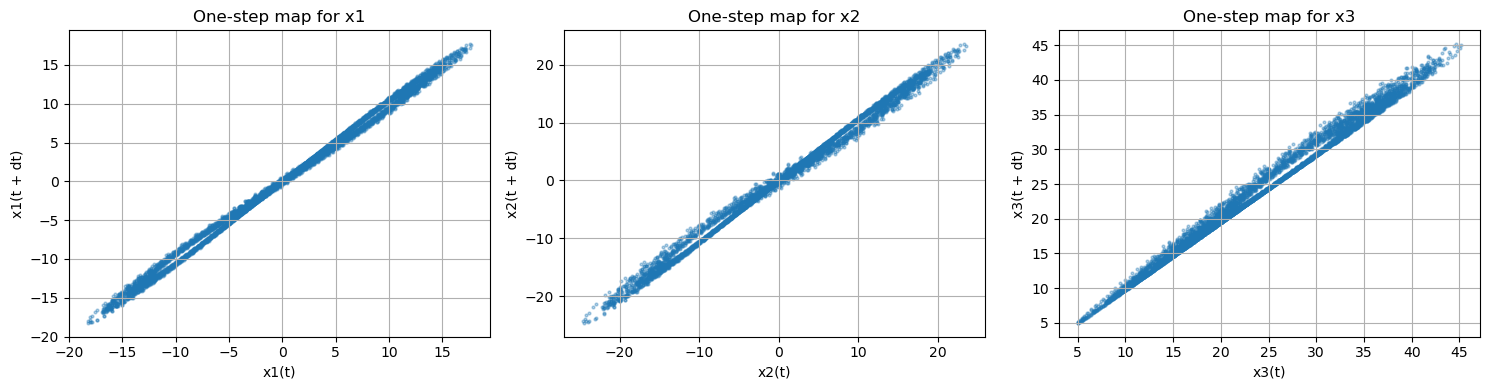

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["x1", "x2", "x3"]

for i in range(3):
    axes[i].scatter(x_train[:, i], y_train[:, i], s=4, alpha=0.35)
    axes[i].set_xlabel(f"{labels[i]}(t)")
    axes[i].set_ylabel(f"{labels[i]}(t + dt)")
    axes[i].set_title(f"One-step map for {labels[i]}")

plt.tight_layout()
plt.show()

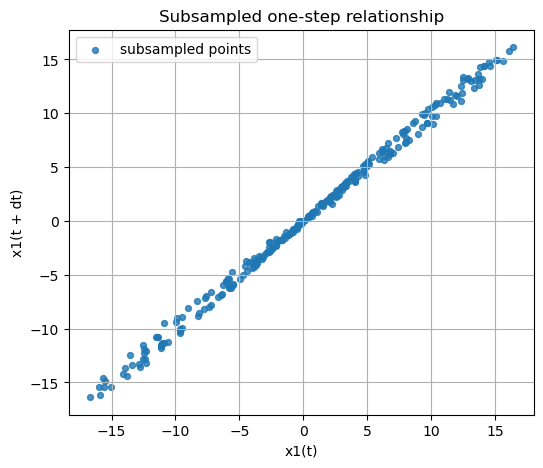

In [9]:
indices = np.arange(0, x_train.shape[0], 25)
plt.figure(figsize=(6, 5))
plt.scatter(
    x_train[indices, 0],
    y_train[indices, 0],
    s=18,
    alpha=0.8,
    label="subsampled points",
)
plt.xlabel("x1(t)")
plt.ylabel("x1(t + dt)")
plt.title("Subsampled one-step relationship")
plt.legend()
plt.show()

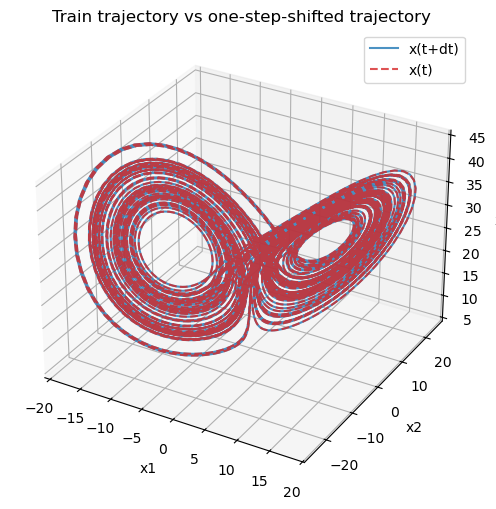

In [17]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot(y_train[:, 0], y_train[:, 1], y_train[:, 2], color="tab:blue", alpha=0.8, label="x(t+dt)")
ax.plot(x_train[:, 0], x_train[:, 1], x_train[:, 2], color="tab:red",linestyle="--", alpha=0.8, label="x(t)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Train trajectory vs one-step-shifted trajectory")
ax.legend()
plt.show()

Observation: for small `dt`, one-step transitions appear smooth and near-linear locally.

This is why short-horizon prediction can look easy even in a chaotic system.
Long-horizon behavior remains highly sensitive to initial conditions.

## 4) 4D-Var Baseline

We now estimate an initial state from noisy partial observations (only `x1`) over a finite window.

In [11]:
# Assimilation setup
L = 250  # shorter window improves robustness/speed for live demo
t_assim = t[:L]
x_true_window = x[:L]

obs_step = 8
sigma_y = 0.05

# Background state = mildly perturbed truth at initial time
x_b = x_true_window[0] + rng.normal(0.0, 1.0, size=3)

print("Assimilation setup")
print(f"L={L}, obs_step={obs_step}, sigma_y={sigma_y}")
print(f"Background initial state: {x_b}")

Assimilation setup
L=250, obs_step=8, sigma_y=0.05
Background initial state: [ 8.30471708 -1.03998411 30.7504512 ]


In [12]:
# Run one 4D-Var reconstruction
exp = run_4dvar(
    x_true_window=x_true_window,
    x_b_initial=x_b,
    obs_step=obs_step,
    sigma_y=sigma_y,
    L=L,
    dt=dt,
    sigma=sigma,
    rho=rho,
    beta_lorenz=beta_lorenz,
    rng=rng,
    maxiter=200,
    )

res = exp["result"]
obs_indices = exp["obs_indices"]
y_obs = exp["y_obs"]
x_analysis_traj = exp["x_analysis"]
x_background_traj = exp["x_background"]

print("Optimization diagnostics")
print(f"success={res.success}, status={res.status}, nit={res.nit}")
print(f"final cost={res.fun:.4f}, RMSE={exp['rmse']:.4f}")

Optimization diagnostics
success=True, status=0, nit=34
final cost=10.1962, RMSE=0.0193


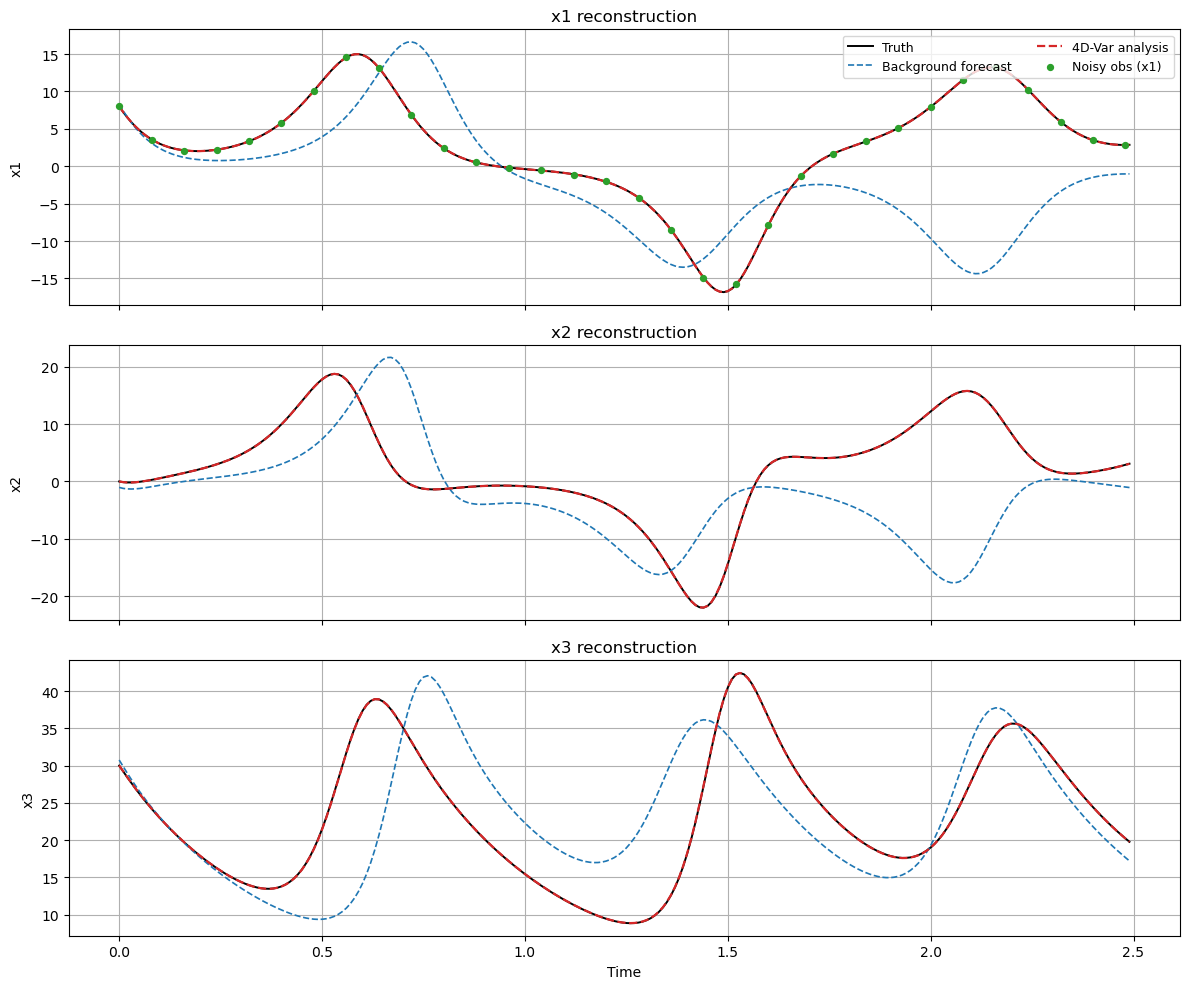

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
labels = ["x1", "x2", "x3"]

for i in range(3):
    axs[i].plot(t_assim, x_true_window[:, i], color="black", linewidth=1.4, label="Truth")
    axs[i].plot(
        t_assim,
        x_background_traj[:, i],
        color="tab:blue",
        linestyle="--",
        linewidth=1.2,
        label="Background forecast",
    )
    axs[i].plot(t_assim, x_analysis_traj[:, i], color="tab:red",linestyle="--", linewidth=1.6, label="4D-Var analysis")

    if i == 0:
        axs[i].scatter(t_assim[obs_indices], y_obs, color="tab:green", s=18, zorder=5, label="Noisy obs (x1)")

    axs[i].set_ylabel(labels[i])
    axs[i].set_title(f"{labels[i]} reconstruction")
    if i == 0:
        axs[i].legend(loc="upper right", ncol=2, fontsize=9)

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### Initial-State Comparison

4D-Var should move the initial condition estimate from the background closer to the true state.

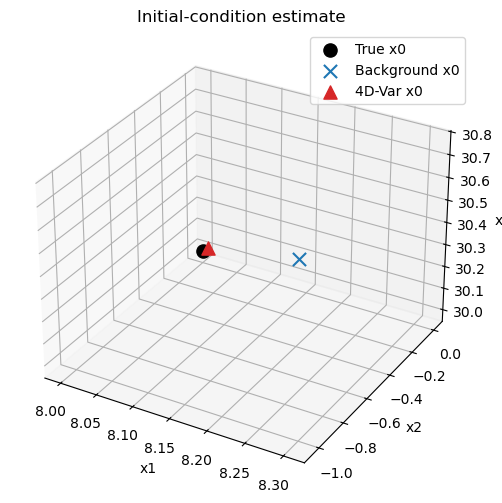

In [14]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(*x_true_window[0], color="black", s=90, marker="o", label="True x0")
ax.scatter(*x_b, color="tab:blue", s=90, marker="x", label="Background x0")
ax.scatter(*res.x, color="tab:red", s=90, marker="^", label="4D-Var x0")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Initial-condition estimate")
ax.legend()
plt.show()

## 5) Sensitivity Analysis

We examine how reconstruction quality changes with:
- Observation frequency (`obs_step`)
- Observation noise (`sigma_y`)

To reduce randomness in conclusions, each configuration is averaged over multiple trials.

### 5.1 Vary Observation Frequency

Lower `obs_step` means more frequent observations.

obs_step= 1 | RMSE mean=7.5989, std=3.7979
obs_step= 2 | RMSE mean=5.7077, std=4.6510
obs_step= 4 | RMSE mean=9.5079, std=0.0055
obs_step= 8 | RMSE mean=0.0201, std=0.0059
obs_step=16 | RMSE mean=0.0233, std=0.0170
obs_step=32 | RMSE mean=9.8736, std=0.0033


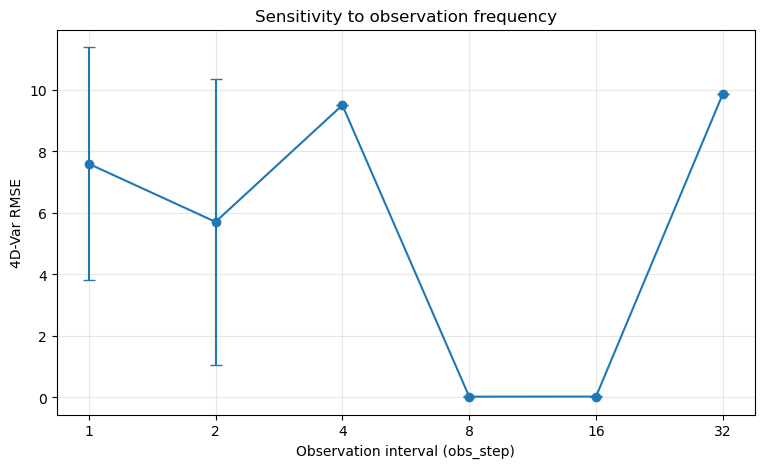

In [15]:
fixed_sigma_y = 0.05
obs_steps_to_test = [1, 2, 4, 8, 16, 32]
n_trials = 5

rmse_mean = []
rmse_std = []

for step in obs_steps_to_test:
    trial_rmses = []
    for trial in range(n_trials):
        local_rng = np.random.default_rng(GLOBAL_SEED + 1000 * step + trial)
        out = run_4dvar(
            x_true_window=x_true_window,
            x_b_initial=x_b,
            obs_step=step,
            sigma_y=fixed_sigma_y,
            L=L,
            dt=dt,
            sigma=sigma,
            rho=rho,
            beta_lorenz=beta_lorenz,
            rng=local_rng,
            maxiter=120,
        )
        trial_rmses.append(out["rmse"])
    rmse_mean.append(np.mean(trial_rmses))
    rmse_std.append(np.std(trial_rmses))
    print(f"obs_step={step:>2} | RMSE mean={rmse_mean[-1]:.4f}, std={rmse_std[-1]:.4f}")

plt.figure(figsize=(9, 5))
plt.errorbar(obs_steps_to_test, rmse_mean, yerr=rmse_std, marker="o", capsize=4)
plt.xscale("log", base=2)
plt.xticks(obs_steps_to_test, [str(s) for s in obs_steps_to_test])
plt.xlabel("Observation interval (obs_step)")
plt.ylabel("4D-Var RMSE")
plt.title("Sensitivity to observation frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 Vary Observation Noise

Higher `sigma_y` means noisier observations.

sigma_y=0.01 | RMSE mean=0.0027, std=0.0012
sigma_y=0.03 | RMSE mean=0.0169, std=0.0047


/tmp/ipykernel_1660718/264648509.py:52: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  traj = odeint(lorenz63_ode, x0_guess, t_eval, args=(sigma, rho, beta_lorenz))


sigma_y=0.05 | RMSE mean=0.0236, std=0.0054
sigma_y=0.10 | RMSE mean=0.0523, std=0.0213
sigma_y=0.20 | RMSE mean=0.0796, std=0.0231
sigma_y=0.50 | RMSE mean=0.2790, std=0.0583
sigma_y=1.00 | RMSE mean=2.2703, std=3.6919


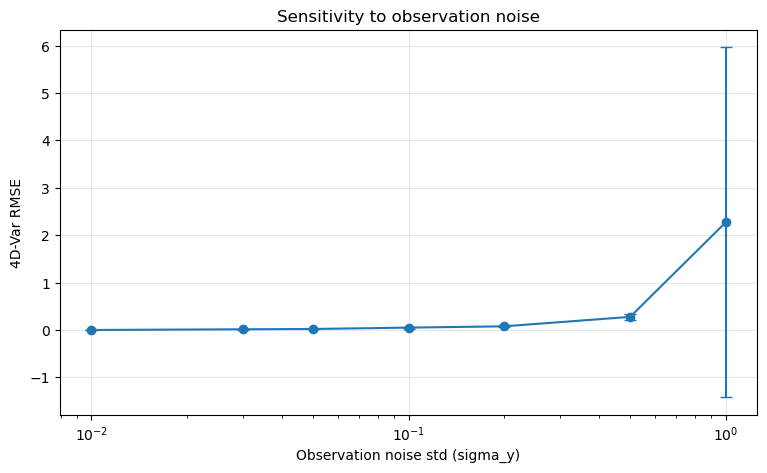

In [16]:
fixed_obs_step = 8
sigma_ys_to_test = [0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0]
n_trials = 5

rmse_mean_noise = []
rmse_std_noise = []

for i, s_y in enumerate(sigma_ys_to_test):
    trial_rmses = []
    for trial in range(n_trials):
        local_rng = np.random.default_rng(GLOBAL_SEED + 2000 * i + trial)
        out = run_4dvar(
            x_true_window=x_true_window,
            x_b_initial=x_b,
            obs_step=fixed_obs_step,
            sigma_y=s_y,
            L=L,
            dt=dt,
            sigma=sigma,
            rho=rho,
            beta_lorenz=beta_lorenz,
            rng=local_rng,
            maxiter=120,
        )
        trial_rmses.append(out["rmse"])
    rmse_mean_noise.append(np.mean(trial_rmses))
    rmse_std_noise.append(np.std(trial_rmses))
    print(f"sigma_y={s_y:>4.2f} | RMSE mean={rmse_mean_noise[-1]:.4f}, std={rmse_std_noise[-1]:.4f}")

plt.figure(figsize=(9, 5))
plt.errorbar(sigma_ys_to_test, rmse_mean_noise, yerr=rmse_std_noise, marker="o", capsize=4)
plt.xscale("log")
plt.xlabel("Observation noise std (sigma_y)")
plt.ylabel("4D-Var RMSE")
plt.title("Sensitivity to observation noise")
plt.grid(True, alpha=0.3)
plt.show()